In [1]:
%matplotlib inline
import pandas as pd
from getdist import plots
from getdist import MCSamples

import matplotlib.pyplot as plt
import numpy as np
from cosmosis.postprocess import parser
from cosmosis.postprocessing.inputs import read_input
from cosmosis.postprocessing.postprocess import postprocessor_for_sampler
from cosmosis.postprocessing.plots import (
    MetropolisHastingsPlots2D,
    MetropolisHastingsPlots1D,
)


import math
from IPython.display import display, Math
import sys
sys.path.append("../../")
from clpipeline.utils.cosmosis_mcmc_plots import plot_triangle, ChainStyle, PlotConfig, chains_to_fits, _load_cosmosis_chain

## BASELINE

LOADING CHAIN FROM FILE:  ./baseline//cosmodc2_redmapper_full_analysis/run_in2p3_mor/outputs_mor/output_rp/number_counts_samples.txt
Removed no burn in
  Counts + Lensing: 141,400 samples  (./baseline//cosmodc2_redmapper_full_analysis/run_in2p3_mor/outputs_mor/output_rp/number_counts_samples.txt)
LOADING CHAIN FROM FILE:  ./baseline//cosmodc2_redmapper_lensing/run_in2p3_mor/outputs_mor/output_rp/number_counts_samples.txt
Removed no burn in
  Lensing: 74,200 samples  (./baseline//cosmodc2_redmapper_lensing/run_in2p3_mor/outputs_mor/output_rp/number_counts_samples.txt)
LOADING CHAIN FROM FILE:  ./baseline//cosmodc2_redmapper_counts/run_in2p3_mor/outputs_mor/output_rp/number_counts_samples.txt
Removed no burn in
  Cluster Counts: 74,200 samples  (./baseline//cosmodc2_redmapper_counts/run_in2p3_mor/outputs_mor/output_rp/number_counts_samples.txt)

Saved to figures/mor_baseline.pdf


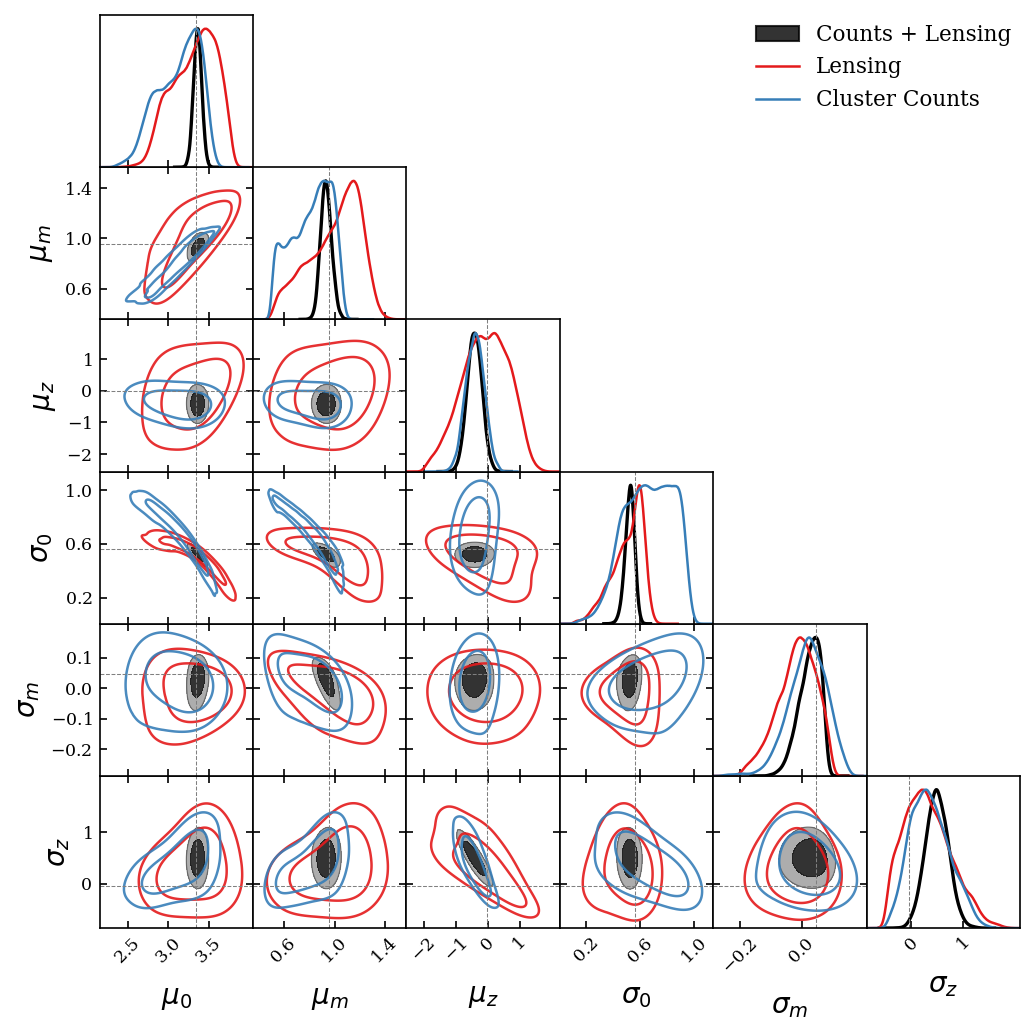


── Counts + Lensing ──


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

...

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

LOADING CHAIN FROM FILE:  ./baseline//cosmodc2_redmapper_full_analysis/run_in2p3_both/outputs_both/output_rp/number_counts_samples.txt
Removed no burn in
  Counts + Lensing: 1,426,600 samples  (./baseline//cosmodc2_redmapper_full_analysis/run_in2p3_both/outputs_both/output_rp/number_counts_samples.txt)
LOADING CHAIN FROM FILE:  ./baseline//cosmodc2_redmapper_lensing/run_in2p3_both/outputs_both/output_rp/number_counts_samples.txt
Removed no burn in
  Lensing: 1,034,600 samples  (./baseline//cosmodc2_redmapper_lensing/run_in2p3_both/outputs_both/output_rp/number_counts_samples.txt)
LOADING CHAIN FROM FILE:  ./baseline//cosmodc2_redmapper_counts/run_in2p3_both/outputs_both/output_rp/number_counts_samples.txt
Removed no burn in
  Cluster Counts: 1,062,600 samples  (./baseline//cosmodc2_redmapper_counts/run_in2p3_both/outputs_both/output_rp/number_counts_samples.txt)

Saved to figures/full_fit_baseline.pdf


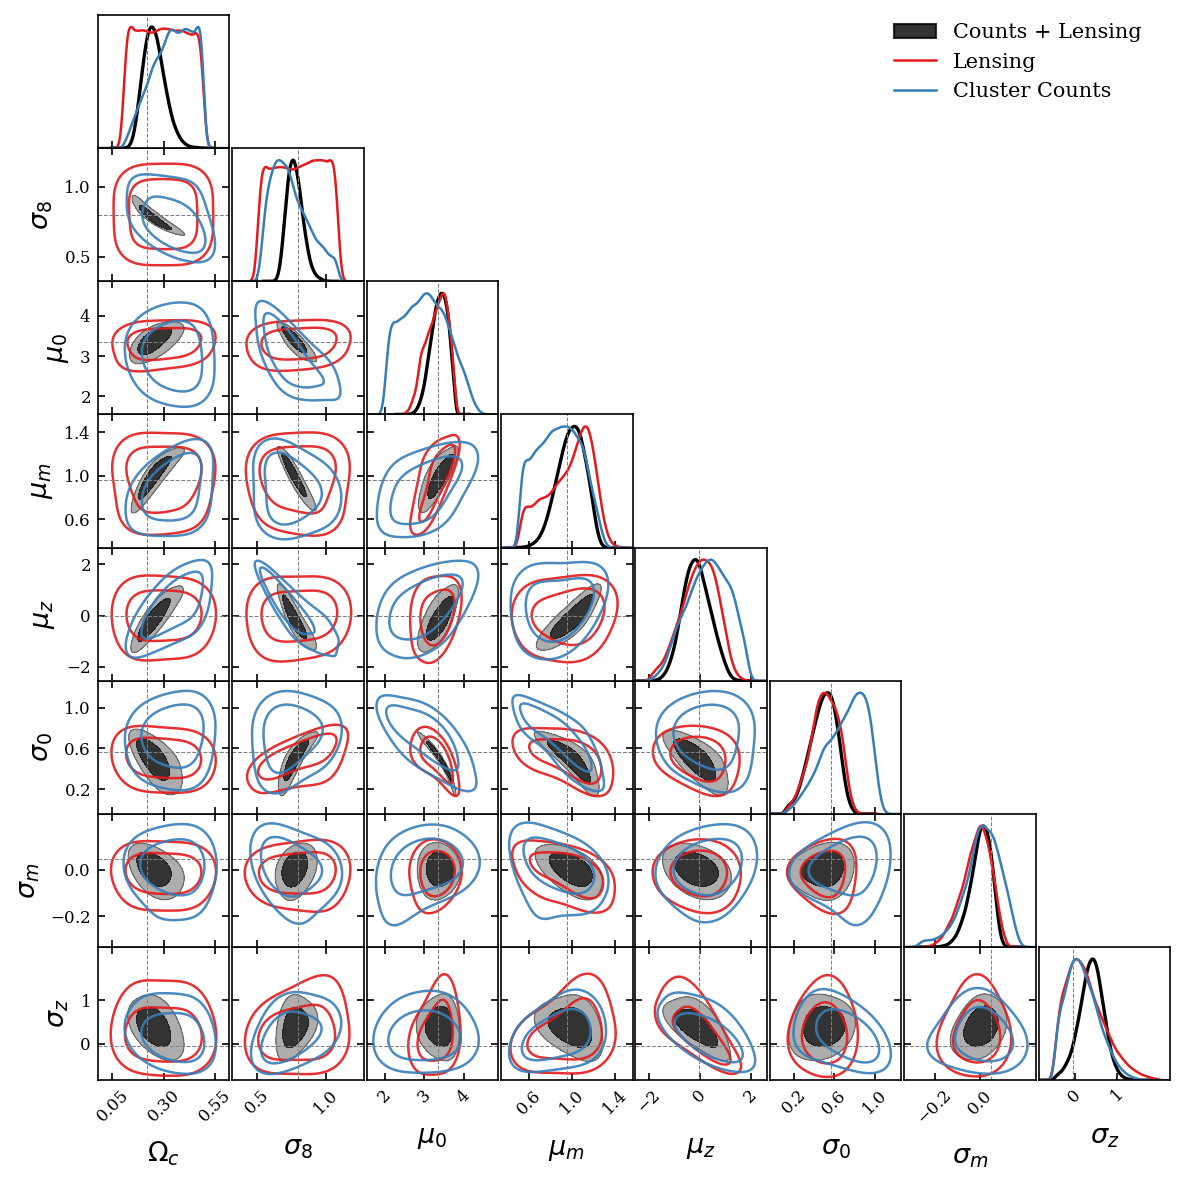


── Counts + Lensing ──


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

...

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

LOADING CHAIN FROM FILE:  ./baseline//cosmodc2_redmapper_full_analysis/run_in2p3_cosmo/outputs_cosmo/output_rp/number_counts_samples.txt
Removed no burn in
  Counts + Lensing: 19,600 samples  (./baseline//cosmodc2_redmapper_full_analysis/run_in2p3_cosmo/outputs_cosmo/output_rp/number_counts_samples.txt)
LOADING CHAIN FROM FILE:  ./baseline//cosmodc2_redmapper_lensing/run_in2p3_cosmo/outputs_cosmo/output_rp/number_counts_samples.txt
Removed no burn in
  Lensing: 29,400 samples  (./baseline//cosmodc2_redmapper_lensing/run_in2p3_cosmo/outputs_cosmo/output_rp/number_counts_samples.txt)
LOADING CHAIN FROM FILE:  ./baseline//cosmodc2_redmapper_counts/run_in2p3_cosmo/outputs_cosmo/output_rp/number_counts_samples.txt
Removed no burn in
  Cluster Counts: 25,200 samples  (./baseline//cosmodc2_redmapper_counts/run_in2p3_cosmo/outputs_cosmo/output_rp/number_counts_samples.txt)

Saved to figures/cosmo_baseline.pdf


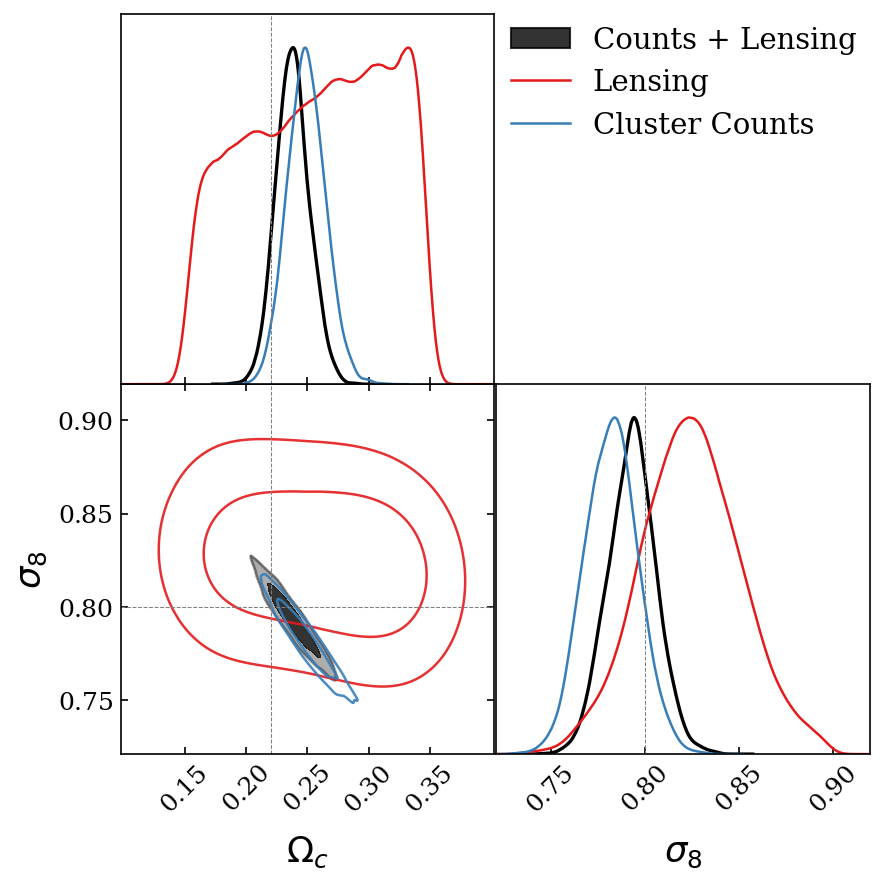


── Counts + Lensing ──


<IPython.core.display.Math object>

<IPython.core.display.Math object>


── Lensing ──


<IPython.core.display.Math object>

<IPython.core.display.Math object>


── Cluster Counts ──


<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [2]:
import sys
sys.path.append("../../")
from clpipeline.utils.cosmosis_mcmc_plots import plot_triangle, ChainStyle, PlotConfig, chains_to_fits

getdist_settings = {
    'mult_bias_correction_order': 0,
    'smooth_scale_2D': 4,
    'smooth_scale_1D': 2,
    'boundary_correction_order': 0,
}


DIR = "./baseline/"

def chain(subdir, run):
    return f"{DIR}/{subdir}/run_in2p3_{run}/outputs_{run}/output_rp/number_counts_samples.txt"

SUBDIRS = {
    "full":    "cosmodc2_redmapper_full_analysis",
    "lensing": "cosmodc2_redmapper_lensing",
    "counts":  "cosmodc2_redmapper_counts",
}

paths_mor  = [chain(SUBDIRS[k], "mor")  for k in ("full", "lensing", "counts")]
paths_both = [chain(SUBDIRS[k], "both") for k in ("full", "lensing", "counts")]
paths_cosmo = [chain(SUBDIRS[k], "cosmo") for k in ("full", "lensing", "counts")]

# ── Parameters ────────────────────────────────────────────────────────────────
PARAMS_MOR = [
    (r"\mu_0",     3.34),
    (r"\mu_m",     0.958236982),
    (r"\mu_z",    -0.0192802),
    (r"\sigma_0",  0.562317194),
    (r"\sigma_m",  0.04552506),
    (r"\sigma_z",  -0.0445),
]

PARAMS_BOTH = [
    (r"\Omega_c",  0.22),
    (r"\sigma_8",  0.80),
    *PARAMS_MOR,
]

PARAMS_COSMO = [
    (r"\Omega_c",  0.22),
    (r"\sigma_8",  0.80),
]

# ── Chain styles ──────────────────────────────────────────────────────────────
#   filled=True  → filled contours + solid outline  (the "money" combined chain)
#   filled=False → solid/dashed lines only           (individual probes)

STYLES_3 = [
    ChainStyle("Counts + Lensing", filled=True,  linestyle="-", fill_alpha=0.8, linewidth=1.6),
    ChainStyle("Lensing",          filled=False, linestyle="-",   linewidth=1.2),
    ChainStyle("Cluster Counts",   filled=False, linestyle="-",  linewidth=1.2),
]

# ── Config ────────────────────────────────────────────────────────────────────
cfg_2par = PlotConfig(figsize=6, output_dir="./figures", burn_fraction=0.3)
cfg_6par = PlotConfig(figsize=7, output_dir="./figures", burn_fraction=0.3)
cfg_8par = PlotConfig(figsize=8, output_dir="./figures", burn_fraction=0.3)

# ── Plot ──────────────────────────────────────────────, save=False────────────────────────
samples_mor  = plot_triangle(paths_mor,  PARAMS_MOR,  STYLES_3, name="mor_baseline",      config=cfg_6par, save=True)
samples_both = plot_triangle(paths_both, PARAMS_BOTH, STYLES_3, name="full_fit_baseline",  config=cfg_8par, save=True)
samples_cosmo = plot_triangle(paths_cosmo, PARAMS_COSMO, STYLES_3, name="cosmo_baseline",  config=cfg_2par, save=True)

# chains_to_fits(
#     samples    = samples_mor,
#     params     = PARAMS_MOR,
#     labels     = ["mor_full", "mor_lensing", "mor_counts"],
#     output_dir = "./chains/",
# )

# chains_to_fits(
#     samples    = samples_both,
#     params     = PARAMS_BOTH,
#     labels     = ["both_full", "both_lensing", "both_counts"],
#     output_dir = "./chains/",
# )



LOADING CHAIN FROM FILE:  ./baseline//cosmodc2_redmapper_full_analysis/run_in2p3_both/outputs_both/output_rp/number_counts_samples.txt
Removed no burn in
  Counts + Lensing: 1,426,600 samples  (./baseline//cosmodc2_redmapper_full_analysis/run_in2p3_both/outputs_both/output_rp/number_counts_samples.txt)


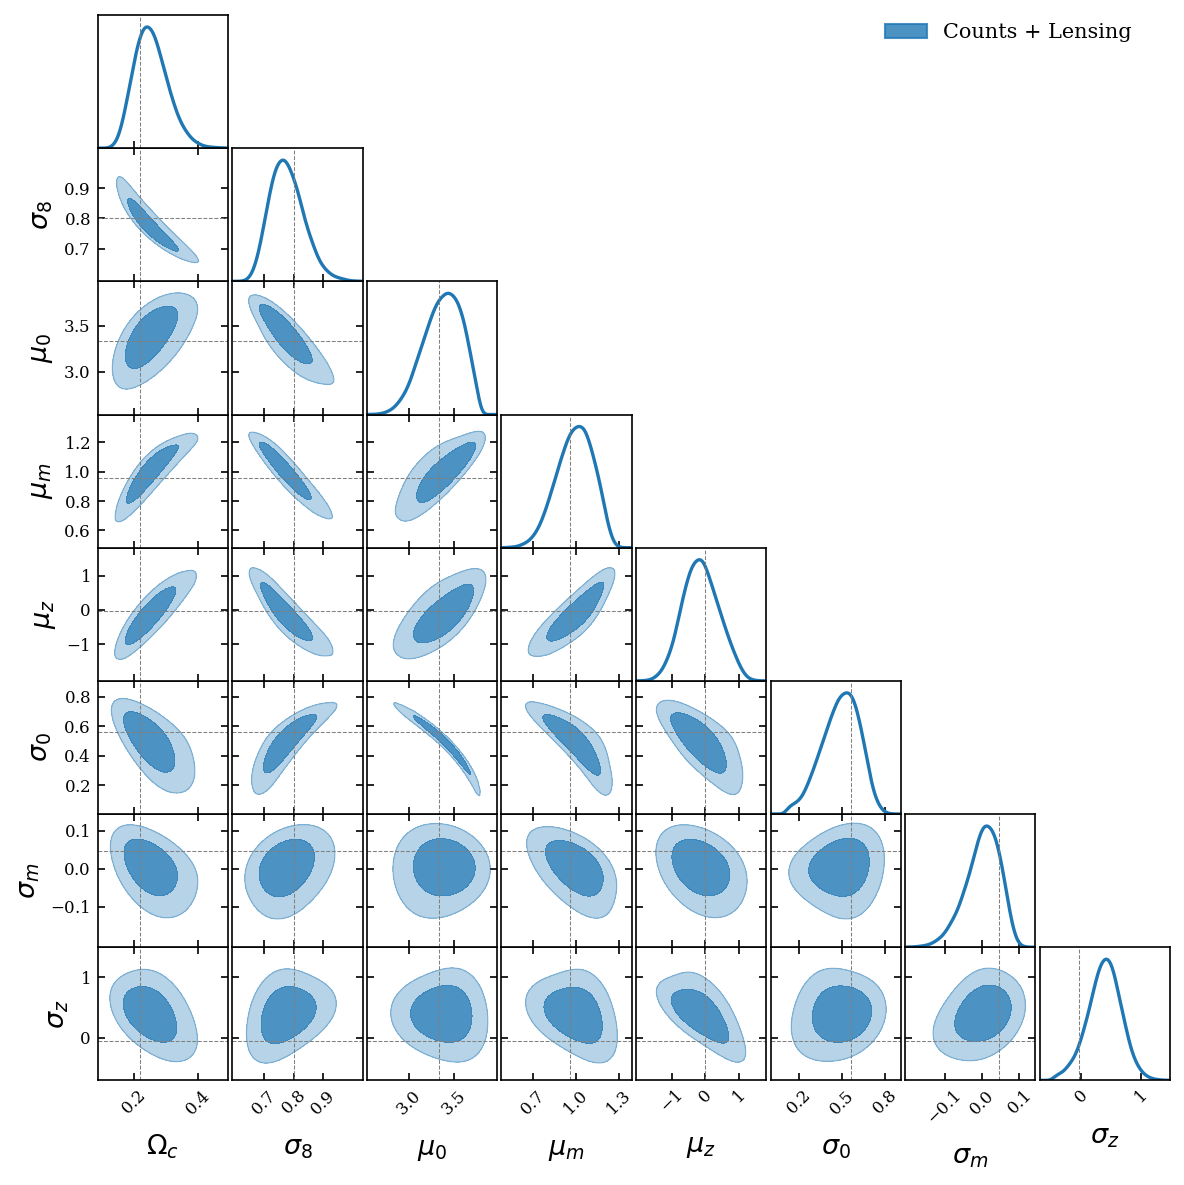


── Counts + Lensing ──


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [3]:
STYLES_paper = [
    ChainStyle("Counts + Lensing", filled=True,  linestyle="-", fill_alpha=0.8, linewidth=1.6, color='#1f77b4'),
]


paper_plot = plot_triangle([paths_both[0]], PARAMS_BOTH, STYLES_paper, name="baseline",  config=cfg_8par, save=False)

In [4]:
##### Best Fit save ######

In [5]:
import os
import numpy as np

full_both_path = paths_both[0]  # full Counts + Lensing, both fit

def read_cosmosis_chain(path):
    header = None

    with open(path, "r") as f:
        for line in f:
            if line.startswith("#"):
                candidate = line[1:].strip().split()
                if "post" in candidate or "like" in candidate or "prior" in candidate:
                    header = candidate
                    break
    data = np.loadtxt(path, comments="#")
    if data.ndim == 1:
        data = data[None, :]

    return header, data


cols, data = read_cosmosis_chain(full_both_path)

print("Columns:")
for i, c in enumerate(cols):
    print(i, c)

# Apply same burn fraction
burn_fraction = cfg_8par.burn_fraction
burn = int(burn_fraction * len(data))
data_use = data[burn:]

# Objective: prefer posterior
if "post" in cols:
    obj_name = "post"
    obj_idx = cols.index("post")
    i_best = np.nanargmax(data_use[:, obj_idx])   # max posterior
elif "like" in cols:
    obj_name = "like"
    obj_idx = cols.index("like")
    i_best = np.nanargmax(data_use[:, obj_idx])   # max likelihood
else:
    raise ValueError("No 'post' or 'like' column found. Cannot define best fit.")

best_obj = data_use[i_best, obj_idx]

# Bookkeeping columns to exclude from parameter output
bookkeeping = {
    "weight",
    "old_weight",
    "like",
    "post",
    "prior",
    "chi2",
    "minuslogpost",
    "minusloglike",
}

param_cols = [c for c in cols if c not in bookkeeping]
param_indices = [cols.index(c) for c in param_cols]

best_fit = data_use[i_best, param_indices]

# Weighted posterior average
if "weight" in cols:
    weights = data_use[:, cols.index("weight")]
    wap = np.average(data_use[:, param_indices], axis=0, weights=weights)
else:
    wap = np.mean(data_use[:, param_indices], axis=0)

os.makedirs("./chains", exist_ok=True)

out_path = "./chains/bestfit_full_both.txt"

with open(out_path, "w") as f:
    f.write("# Full both case: Counts + Lensing\n")
    f.write(f"# Source chain: {full_both_path}\n")
    f.write(f"# Burn fraction: {burn_fraction}\n")
    f.write(f"# Best fit definition: maximum {obj_name}\n")
    f.write(f"# Best {obj_name}: {best_obj:.10e}\n")
    f.write("#\n")
    f.write("# parameter best_fit weighted_average_posterior\n")

    for name, bf, mean in zip(param_cols, best_fit, wap):
        f.write(f"{name:40s} {bf:.10e} {mean:.10e}\n")

print(f"Saved: {out_path}")
print(f"Best {obj_name} = {best_obj:.6g}")
print()

for name, bf, mean in zip(param_cols, best_fit, wap):
    print(f"{name:40s} best_fit = {bf:.8g}   wap = {mean:.8g}")

Columns:
0 cosmological_parameters--omega_c
1 cosmological_parameters--sigma_8
2 firecrown_number_counts--mass_distribution_mu0
3 firecrown_number_counts--mass_distribution_mu1
4 firecrown_number_counts--mass_distribution_mu2
5 firecrown_number_counts--mass_distribution_sigma0
6 firecrown_number_counts--mass_distribution_sigma1
7 firecrown_number_counts--mass_distribution_sigma2
8 prior
9 post
Saved: ./chains/bestfit_full_both.txt
Best post = -119.516

cosmological_parameters--omega_c         best_fit = 0.22370613   wap = 0.25505612
cosmological_parameters--sigma_8         best_fit = 0.78845163   wap = 0.77746117
firecrown_number_counts--mass_distribution_mu0 best_fit = 3.4334793   wap = 3.378816
firecrown_number_counts--mass_distribution_mu1 best_fit = 0.92793217   wap = 0.99314739
firecrown_number_counts--mass_distribution_mu2 best_fit = -0.29343203   wap = -0.13094693
firecrown_number_counts--mass_distribution_sigma0 best_fit = 0.49620235   wap = 0.48919998
firecrown_number_counts--

## Compare CLCosmoSim

In [6]:
from astropy.table import Table
import numpy as np
from getdist import MCSamples, plots

# ------------------------------------------------------------
# CROW convention
# ------------------------------------------------------------

names = ['1', '2', '3', '4', '5', '6']

labels = [
    r'\ln \lambda_0',
    r'\mu_m',
    r'\mu_z',
    r'\sigma_{\ln \lambda, 0}',
    r'\sigma_m',
    r'\sigma_z',
]

settings_alone = {
    'mult_bias_correction_order': 0,
    'smooth_scale_2D': 4,
    'smooth_scale_1D': 2,
    'boundary_correction_order': 0,
}

settings = settings_alone.copy()

n_cut = 19000


PARAMS_MOR = [
    (r"\mu_0",     3.34),
    (r"\mu_m",     0.958236982),
    (r"\mu_z",    -0.0192802),
    (r"\sigma_0",  0.562317194),
    (r"\sigma_m",  0.04552506),
    (r"\sigma_z", -0.0445),
]

markers = dict(zip(names, [x[1] for x in PARAMS_MOR]))


# ------------------------------------------------------------
# Helpers
# ------------------------------------------------------------

def clcosmo_to_crow_order(samples):
    """
    Convert CLCosmoSim/Payerne chains to CROW convention.

    Input order:
        [mu0, mu_z, mu_m_ln, sigma0, sigma_z, sigma_m_ln]

    Output order:
        [mu0, mu_m_log10, mu_z, sigma0, sigma_m_log10, sigma_z]
    """

    s = np.asarray(samples)

    out = np.column_stack([
        s[:, 0],              # mu0
        s[:, 2] / np.log(10), # mu_m
        s[:, 1],              # mu_z
        s[:, 3],              # sigma0
        s[:, 5] / np.log(10), # sigma_m
        s[:, 4],              # sigma_z
    ])

    return out


def load_clcosmo_chain(path, label, settings=settings_alone):
    t = np.load(path, allow_pickle=True)

    samples = clcosmo_to_crow_order(t['flat_chains'][n_cut:])

    return MCSamples(
        samples=samples,
        names=names,
        labels=labels,
        settings=settings,
        label=label,
    )


def load_crow_chain(path, label, settings=settings_alone):
    t = Table.read(path)

    # No rescaling, no reordering
    samples = np.vstack([t[col] for col in t.colnames]).T

    return MCSamples(
        samples=samples,
        names=names,
        labels=labels,
        settings=settings,
        label=label,
    )
def plot_crow_vs_clcosmo(crow_chain, clcosmo_chain, params=names):
    g = plots.get_subplot_plotter(subplot_size=1)

    g.settings.lab_fontsize = 20
    g.settings.legend_fontsize = 15
    g.settings.axes_fontsize = 15

    marker_args = {
        'lw': 0.75,
        'markersize': 0.75,
        'ls': '--',
        'color': '0.35',
    }

    g.triangle_plot(
        [crow_chain, clcosmo_chain],
        filled=[True, False, False],
        contour_colors=['tab:blue', 'k'],
        contour_ls=['-', '--'],
        contour_lws=[1.0, 1.2],
        legend_fontsize=10,
        params=params,
        markers=markers,
        fine_bins_2D=5,
        marker_args=marker_args,
    )

    return g

In [7]:
name = '1-halo=nfw+c-M=Duffy08_rmin=1.0-rmax=3.5_photoz=Truez_hmf=Despali16'

M = load_clcosmo_chain(
    f'payerne25chains/M/MCMC_fit_m-r_M_{name}.pkl',
    label='Lensing masses alone',
)

N = load_clcosmo_chain(
    'payerne25chains/N/MCMC_fit_m-r_N_low_z_sample_hmf=Despali16.pkl',
    label='Abundance alone (Payerne25 z < 0.8)',
)

WL = load_clcosmo_chain(
    'payerne25chains/WL/MCMC_fit_m-r_WL_1-halo=nfw+c-M=Duffy08_rmin=1.0-rmax=3.5_photoz=Truez_low_richness_sample_hmf=Despali16.pkl',
    label='Lensing alone (Payerne25 z < 0.8)',
)

WLxN = load_clcosmo_chain(
    'payerne25chains/WLxN/MCMC_fit_m-r_WLxN_1-halo=nfw+c-M=Duffy08_rmin=1.0-rmax=3.5_photoz=Truez_low_z_sample_hmf=Despali16.pkl',
    label='Lensing profiles + Abundance (Payerne25 z < 0.8)',
    settings=settings,
)


N_CLPipeline = load_crow_chain(
    "./chains/mor_counts.fits",
    label='Abundance (CLPipeline z < 0.8)',
)

full_CLPipeline = load_crow_chain(
    "./chains/mor_full.fits",
    label='Lensing profiles + Abundance (CLPipeline z < 0.8)',
)
lensing_CLPipeline = load_crow_chain(
    "./chains/mor_lensing.fits",
    label='Lensing profiles alone (CLPipeline z < 0.8)',
)

Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in


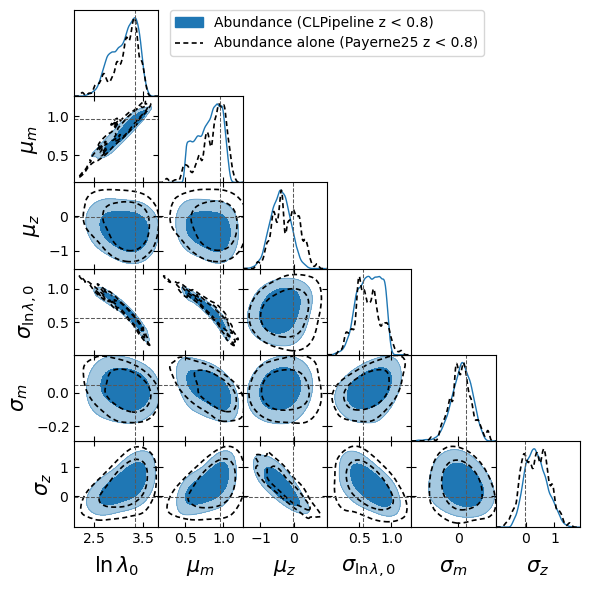

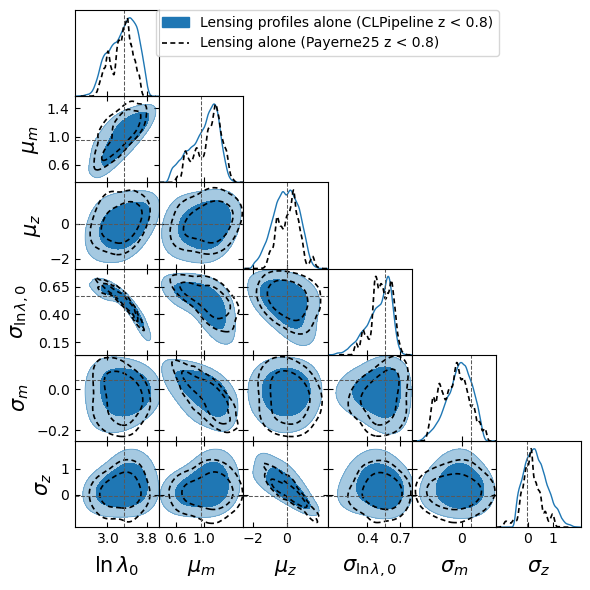

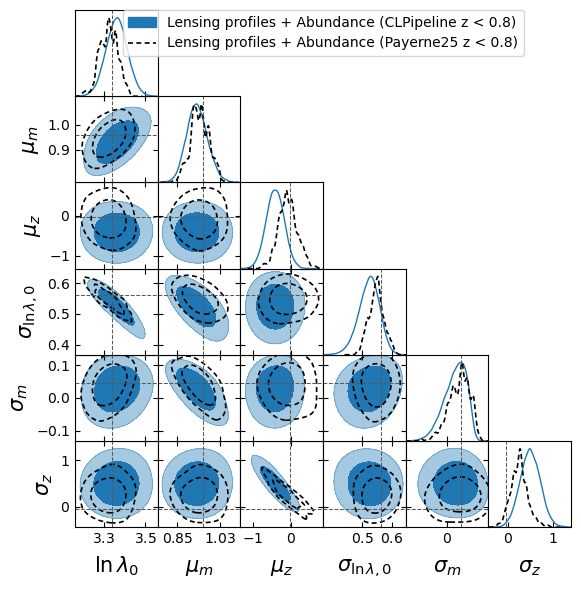

In [8]:
g = plot_crow_vs_clcosmo(N_CLPipeline, N)
plt.savefig("./figures/counts_crow_vs_clcosmo.png", dpi=300, bbox_inches="tight")
g = plot_crow_vs_clcosmo(lensing_CLPipeline, WL)
plt.savefig("./figures/lensing_crow_vs_clcosmo.png", dpi=300, bbox_inches="tight")
g = plot_crow_vs_clcosmo(full_CLPipeline, WLxN)
plt.savefig("./figures/clpipeline_vs_payerne.pdf", dpi=300, bbox_inches="tight")


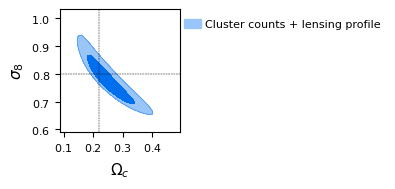

In [9]:
from getdist import plots
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

g = plots.get_subplot_plotter()
combined = samples_both[0]
x_fid, y_fid = 0.22, 0.80

g.plot_2d(
    [combined],
    r"\Omega_c",
    r"\sigma_8",
    filled=True
)

ax = g.subplots[0, 0]
ax.axvline(x_fid, color='k', ls='--', lw=0.35)
ax.axhline(y_fid, color='k', ls='--', lw=0.35)

g.fig.subplots_adjust(right=0.68)

# Get the fill color from the contour and make a proxy patch
contour_color = ax.collections[0].get_facecolor()[0]
proxy = Patch(facecolor=contour_color, edgecolor=contour_color)

ax.legend(
    handles=[proxy],
    labels=["Cluster counts + lensing profile"],
    loc="upper left",
    bbox_to_anchor=(0.95, 1.0),
    frameon=False,
    fontsize=8,
    handlelength=1.5,
    handleheight=0.8,
    handletextpad=0.4,
)

plt.savefig("./figures/cosmodc2_contour.png", bbox_inches='tight', dpi=150)
plt.show()

## HMF

LOADING CHAIN FROM FILE:  ./hmf_analysis//bocquet16/run_in2p3_mor/outputs_mor/output_rp/number_counts_samples.txt
Removed no burn in
  bocquet16: 40,600 samples  (./hmf_analysis//bocquet16/run_in2p3_mor/outputs_mor/output_rp/number_counts_samples.txt)
LOADING CHAIN FROM FILE:  ./hmf_analysis//tinker08/run_in2p3_mor/outputs_mor/output_rp/number_counts_samples.txt
Removed no burn in
  tinker08: 30,800 samples  (./hmf_analysis//tinker08/run_in2p3_mor/outputs_mor/output_rp/number_counts_samples.txt)
LOADING CHAIN FROM FILE:  ./hmf_analysis//tinker10/run_in2p3_mor/outputs_mor/output_rp/number_counts_samples.txt
Removed no burn in
  tinker10: 26,600 samples  (./hmf_analysis//tinker10/run_in2p3_mor/outputs_mor/output_rp/number_counts_samples.txt)
LOADING CHAIN FROM FILE:  ./hmf_analysis//watson13/run_in2p3_mor/outputs_mor/output_rp/number_counts_samples.txt
Removed no burn in
  watson13: 42,000 samples  (./hmf_analysis//watson13/run_in2p3_mor/outputs_mor/output_rp/number_counts_samples.txt)
L

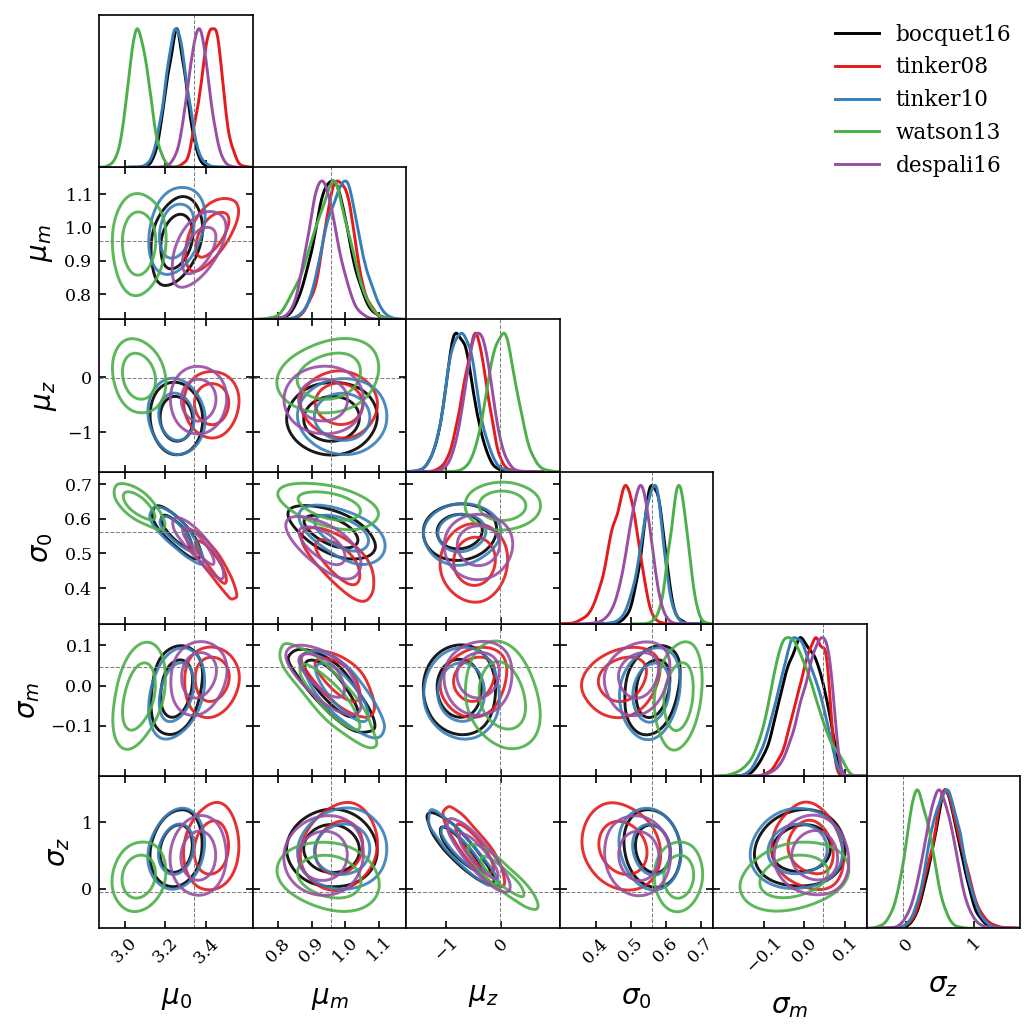


── bocquet16 ──


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

...

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

LOADING CHAIN FROM FILE:  ./hmf_analysis//bocquet16/run_in2p3_both/outputs_both/output_rp/number_counts_samples.txt
Removed no burn in
  bocquet16: 820,800 samples  (./hmf_analysis//bocquet16/run_in2p3_both/outputs_both/output_rp/number_counts_samples.txt)
LOADING CHAIN FROM FILE:  ./hmf_analysis//tinker08/run_in2p3_both/outputs_both/output_rp/number_counts_samples.txt
Removed no burn in
  tinker08: 615,600 samples  (./hmf_analysis//tinker08/run_in2p3_both/outputs_both/output_rp/number_counts_samples.txt)
LOADING CHAIN FROM FILE:  ./hmf_analysis//tinker10/run_in2p3_both/outputs_both/output_rp/number_counts_samples.txt
Removed no burn in
  tinker10: 543,600 samples  (./hmf_analysis//tinker10/run_in2p3_both/outputs_both/output_rp/number_counts_samples.txt)
LOADING CHAIN FROM FILE:  ./hmf_analysis//watson13/run_in2p3_both/outputs_both/output_rp/number_counts_samples.txt
Removed no burn in
  watson13: 40,800 samples  (./hmf_analysis//watson13/run_in2p3_both/outputs_both/output_rp/number_co

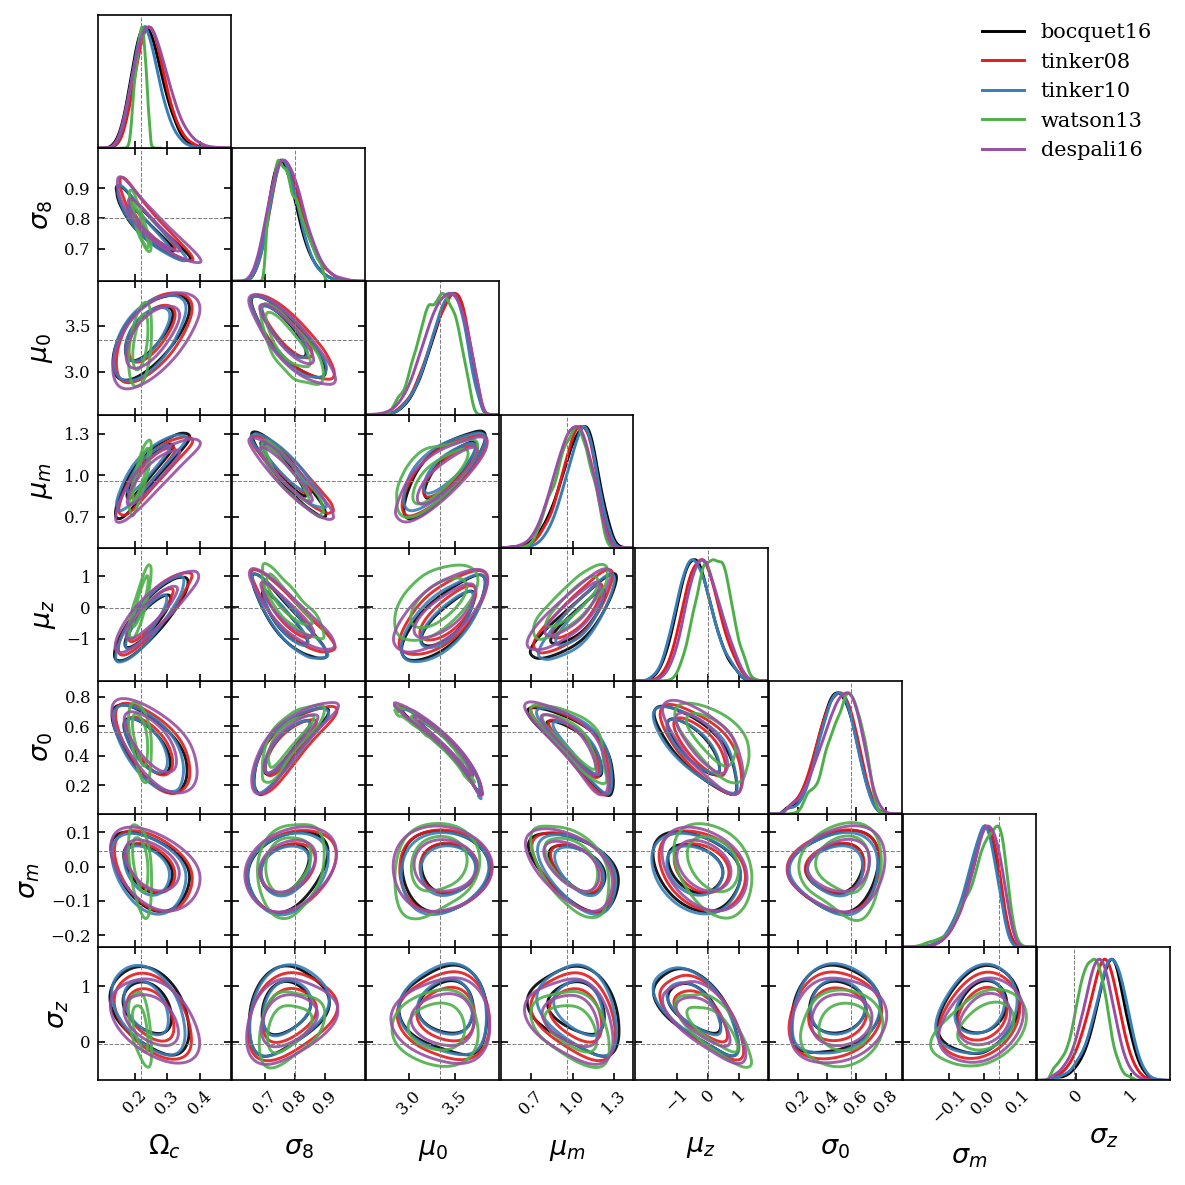


── bocquet16 ──


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

...

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

  Saved 40,600 samples × 6 params → chains/mor_bocquet16.fits
  Saved 30,800 samples × 6 params → chains/mor_tinker08.fits
  Saved 26,600 samples × 6 params → chains/mor_tinker10.fits
  Saved 42,000 samples × 6 params → chains/mor_watson13.fits
  Saved 820,800 samples × 8 params → chains/both_bocquet16.fits
  Saved 615,600 samples × 8 params → chains/both_tinker08.fits
  Saved 543,600 samples × 8 params → chains/both_tinker10.fits
  Saved 40,800 samples × 8 params → chains/both_watson13.fits


[PosixPath('chains/both_bocquet16.fits'),
 PosixPath('chains/both_tinker08.fits'),
 PosixPath('chains/both_tinker10.fits'),
 PosixPath('chains/both_watson13.fits')]

In [10]:
# ── HMF definitions ────────────────────────────────────────────────────────────
HMFS = [
    "bocquet16",
    "tinker08",
    "tinker10",
    "watson13",
]

BASELINE_NAME = "despali16"

HMFS_ALL = HMFS + [BASELINE_NAME]

DIR_HMF = "./hmf_analysis/"


def chain_hmf(subdir, run):
    return f"{DIR_HMF}/{subdir}/run_in2p3_{run}/outputs_{run}/output_rp/number_counts_samples.txt"


# ── Build paths consistently ──────────────────────────────────────────────────
def build_paths(run):
    return [chain_hmf(k, run) for k in HMFS] + [
        f"./"
        f"baseline/cosmodc2_redmapper_full_analysis/run_in2p3_{run}/outputs_{run}/output_rp/number_counts_samples.txt"
    ]


paths_mor   = build_paths("mor")
paths_both  = build_paths("both")
paths_cosmo = build_paths("cosmo")


# ── Parameters ────────────────────────────────────────────────────────────────
PARAMS_MOR = [
    (r"\mu_0",     3.34),
    (r"\mu_m",     0.958236982),
    (r"\mu_z",    -0.0192802),
    (r"\sigma_0",  0.562317194),
    (r"\sigma_m",  0.04552506),
    (r"\sigma_z",  -0.0445),
]

PARAMS_BOTH = [
    (r"\Omega_c",  0.22),
    (r"\sigma_8",  0.80),
    *PARAMS_MOR,
]

PARAMS_COSMO = [
    (r"\Omega_c",  0.22),
    (r"\sigma_8",  0.80),
]


# ── Colors ────────────────────────────────────────────────────────────────────
COLORS = [
    '#000000', '#e41a1c', '#377eb8', '#4daf4a', '#984ea3'
]


# ── Styles (STRICT 1:1 with paths) ───────────────────────────────────────────
styles_hmf = [
    ChainStyle(
        name,
        filled=False,
        linewidth=1.4,
        color=COLORS[i % len(COLORS)]
    )
    for i, name in enumerate(HMFS_ALL)
]


# ── Config ────────────────────────────────────────────────────────────────────
cfg_2par = PlotConfig(figsize=7, output_dir="./figures", burn_fraction=0.3)
cfg_6par = PlotConfig(figsize=7, output_dir="./figures", burn_fraction=0.3)
cfg_8par = PlotConfig(figsize=8, output_dir="./figures", burn_fraction=0.4)


# ── Sanity check (optional but recommended) ───────────────────────────────────
# assert len(paths_mor) == len(styles_hmf), "Mismatch in MOR"
# assert len(paths_both) == len(styles_hmf), "Mismatch in BOTH"
# assert len(paths_cosmo) == len(styles_hmf), "Mismatch in COSMO"


# ── Plot ──────────────────────────────────────────────────────────────────────
samples_mor = plot_triangle(
    paths_mor,
    PARAMS_MOR,
    styles_hmf,
    name="mor_baseline",
    config=cfg_6par,
    save=False
)

samples_both = plot_triangle(
    paths_both,
    PARAMS_BOTH,
    styles_hmf,
    name="full_fit_baseline",
    config=cfg_8par,
    save=False
)

chains_to_fits(
    samples=samples_mor[:len(HMFS)],
    params=PARAMS_MOR,
    labels=[f"mor_{hmf}" for hmf in HMFS],
    output_dir="./chains",
)

chains_to_fits(
    samples=samples_both[:len(HMFS)],
    params=PARAMS_BOTH,
    labels=[f"both_{hmf}" for hmf in HMFS],
    output_dir="./chains",
)

## Fiducial Cosmo

LOADING CHAIN FROM FILE:  ./fiducial_cosmology_analysis/cosmo_0.22_0.7/run_in2p3_both/outputs_both/output_rp/number_counts_samples.txt
Removed no burn in
  $\Omega_c=0.22,\ \sigma_8=0.7$: 662,400 samples  (./fiducial_cosmology_analysis/cosmo_0.22_0.7/run_in2p3_both/outputs_both/output_rp/number_counts_samples.txt)
LOADING CHAIN FROM FILE:  ./fiducial_cosmology_analysis/cosmo_0.3_0.9/run_in2p3_both/outputs_both/output_rp/number_counts_samples.txt
Removed no burn in
  $\Omega_c=0.3,\ \sigma_8=0.9$: 68,400 samples  (./fiducial_cosmology_analysis/cosmo_0.3_0.9/run_in2p3_both/outputs_both/output_rp/number_counts_samples.txt)
LOADING CHAIN FROM FILE:  ./fiducial_cosmology_analysis/cosmo_0.4_0.8/run_in2p3_both/outputs_both/output_rp/number_counts_samples.txt
Removed no burn in
  $\Omega_c=0.4,\ \sigma_8=0.8$: 67,200 samples  (./fiducial_cosmology_analysis/cosmo_0.4_0.8/run_in2p3_both/outputs_both/output_rp/number_counts_samples.txt)
LOADING CHAIN FROM FILE:  ./baseline/cosmodc2_redmapper_full

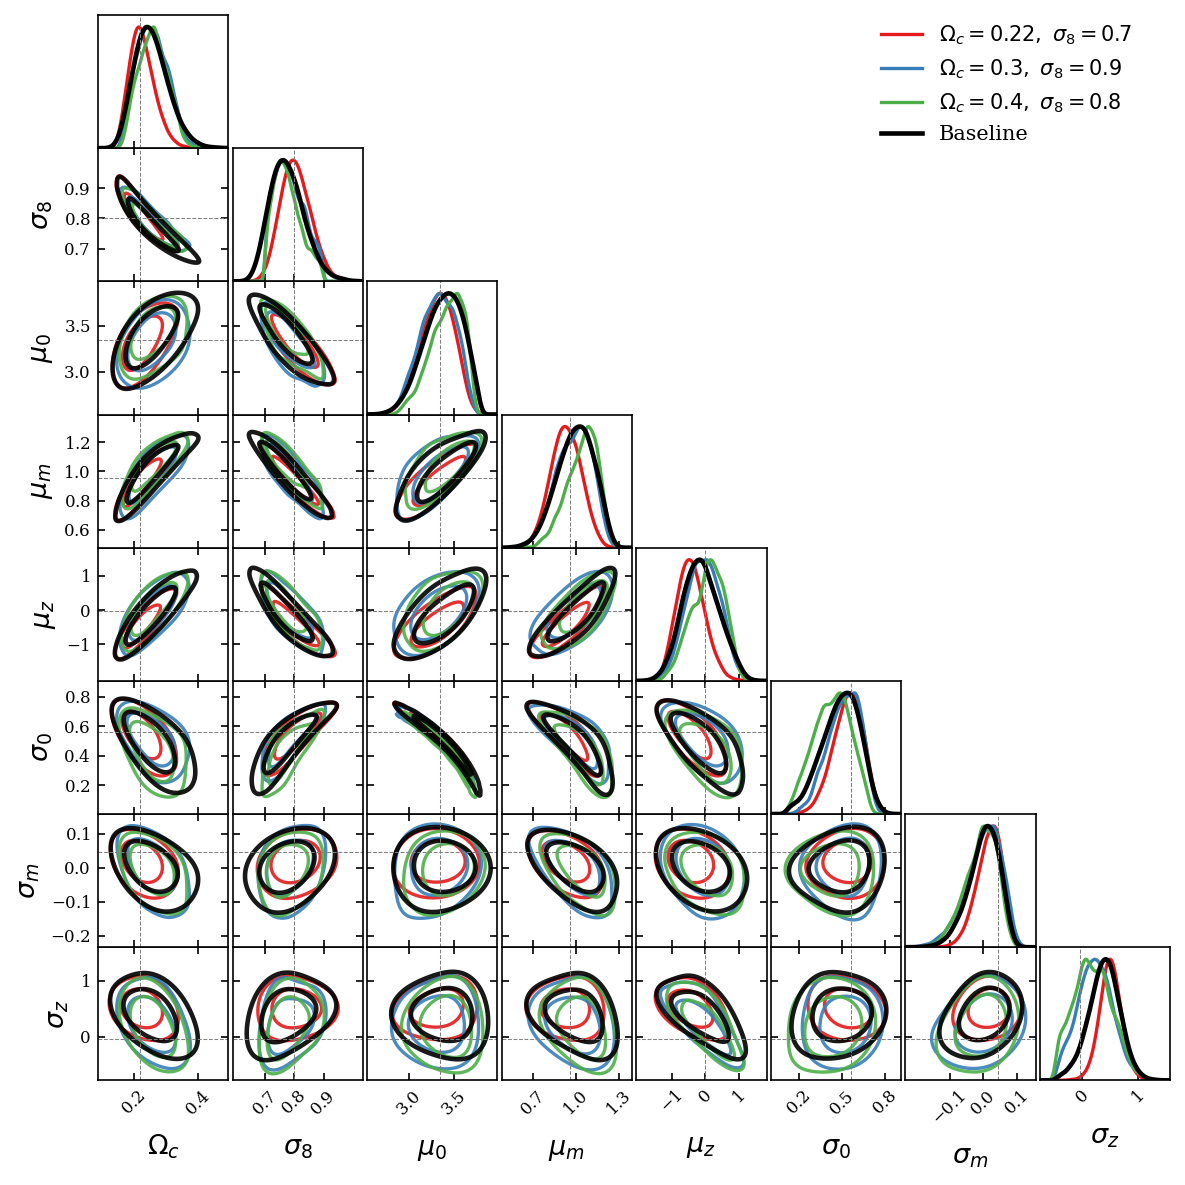


── $\Omega_c=0.22,\ \sigma_8=0.7$ ──


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

...

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

  Saved 662,400 samples × 8 params → chains/both_cosmo_0.22_0.7.fits
  Saved 68,400 samples × 8 params → chains/both_cosmo_0.3_0.9.fits
  Saved 67,200 samples × 8 params → chains/both_cosmo_0.4_0.8.fits


[PosixPath('chains/both_cosmo_0.22_0.7.fits'),
 PosixPath('chains/both_cosmo_0.3_0.9.fits'),
 PosixPath('chains/both_cosmo_0.4_0.8.fits')]

In [11]:
BASE_DIR           = "./fiducial_cosmology_analysis"
BASELINE_PATH      = "./baseline/cosmodc2_redmapper_lensing/run_in2p3_both/outputs_both/output_rp/number_counts_samples.txt"
BASELINE_PATH_BOTH = "./baseline/cosmodc2_redmapper_full_analysis/run_in2p3_both/outputs_both/output_rp/number_counts_samples.txt"

RUNS         = ["cosmo_0.22_0.7",         "cosmo_0.3_0.9",         "cosmo_0.4_0.8"]
PARAMS_BOTH = [
    (r"\Omega_c", 0.22),
    (r"\sigma_8", 0.80),
    (r"\mu_0",    3.34),
    (r"\mu_m",    0.958236982),
    (r"\mu_z",   -0.0192802),
    (r"\sigma_0", 0.562317194),
    (r"\sigma_m", 0.04552506),
    (r"\sigma_z", -0.0445),
]

COLORS = ['#e41a1c', '#377eb8', '#4daf4a', '#000000']

def pretty_name(run):
    parts = run.replace("cosmo_", "").replace("_lensing", "").split("_")
    return rf"$\Omega_c={parts[0]},\ \sigma_8={parts[1]}$"

LABELS = [pretty_name(r) for r in RUNS] + ["Baseline"]

styles_runs = [
    ChainStyle(label, filled=False, linewidth=2.2 if label == "Baseline" else 1.6, color=color)
    for label, color in zip(LABELS, COLORS)
]



def build_paths(runs, lensing=False):
    paths = [f"{BASE_DIR}/{run}/run_in2p3_both/outputs_both/output_rp/number_counts_samples.txt"
             for run in runs]
    paths.append(BASELINE_PATH if lensing else BASELINE_PATH_BOTH)
    return paths


samples_both = plot_triangle(
    build_paths(RUNS, lensing=False),
    PARAMS_BOTH, styles_runs,
    name="cosmo_mor_both_with_baseline", config=cfg_8par, save=False,
)

chains_to_fits(
    samples=samples_both[:-1],
    params=PARAMS_BOTH,
    labels=[f"both_{run}" for run in RUNS],
    output_dir="./chains",
)


## EXCLUDING FIRST BIN

LOADING CHAIN FROM FILE:  ./baseline/cosmodc2_redmapper_full_analysis/run_in2p3_both/outputs_both/output_rp/number_counts_samples.txt
Removed no burn in
  Baseline (all bins): 1,426,600 samples  (./baseline/cosmodc2_redmapper_full_analysis/run_in2p3_both/outputs_both/output_rp/number_counts_samples.txt)
LOADING CHAIN FROM FILE:  ./high_completeness_analysis/exclude_first_rich_bin/run_in2p3_both/outputs_both/output_rp/number_counts_samples.txt
Removed no burn in
  Exclude first richness bin: 519,400 samples  (./high_completeness_analysis/exclude_first_rich_bin/run_in2p3_both/outputs_both/output_rp/number_counts_samples.txt)


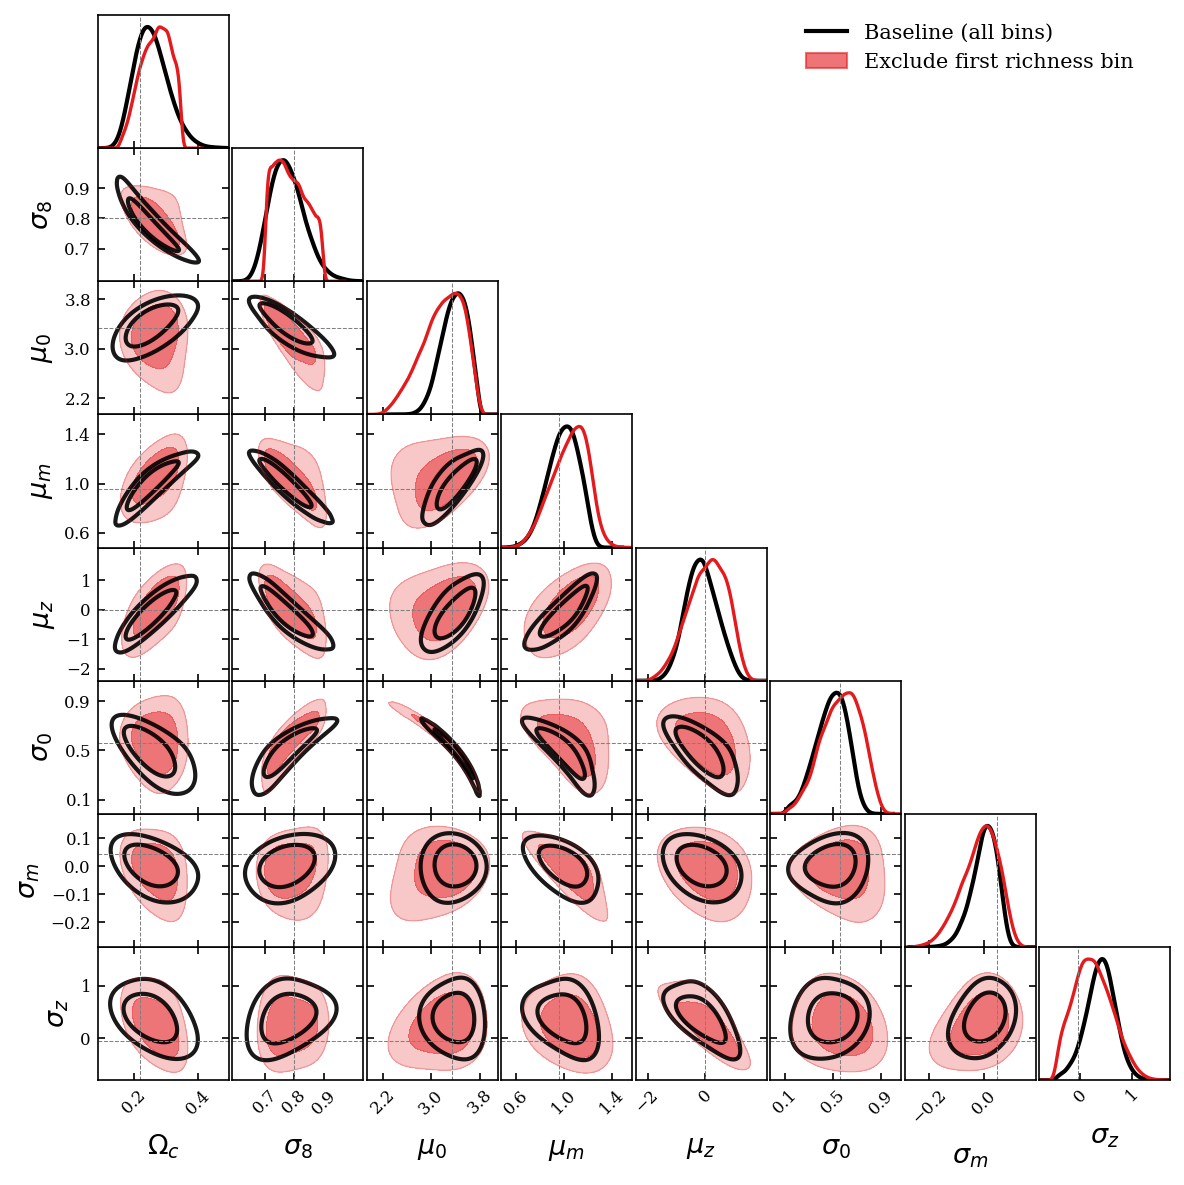


── Baseline (all bins) ──


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

...

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

LOADING CHAIN FROM FILE:  ./baseline/cosmodc2_redmapper_full_analysis/run_in2p3_mor/outputs_mor/output_rp/number_counts_samples.txt
Removed no burn in
  Baseline (all bins): 141,400 samples  (./baseline/cosmodc2_redmapper_full_analysis/run_in2p3_mor/outputs_mor/output_rp/number_counts_samples.txt)
LOADING CHAIN FROM FILE:  ./high_completeness_analysis/exclude_first_rich_bin/run_in2p3_mor/outputs_both/output_rp/number_counts_samples.txt
Removed no burn in
  Exclude first richness bin: 72,800 samples  (./high_completeness_analysis/exclude_first_rich_bin/run_in2p3_mor/outputs_both/output_rp/number_counts_samples.txt)


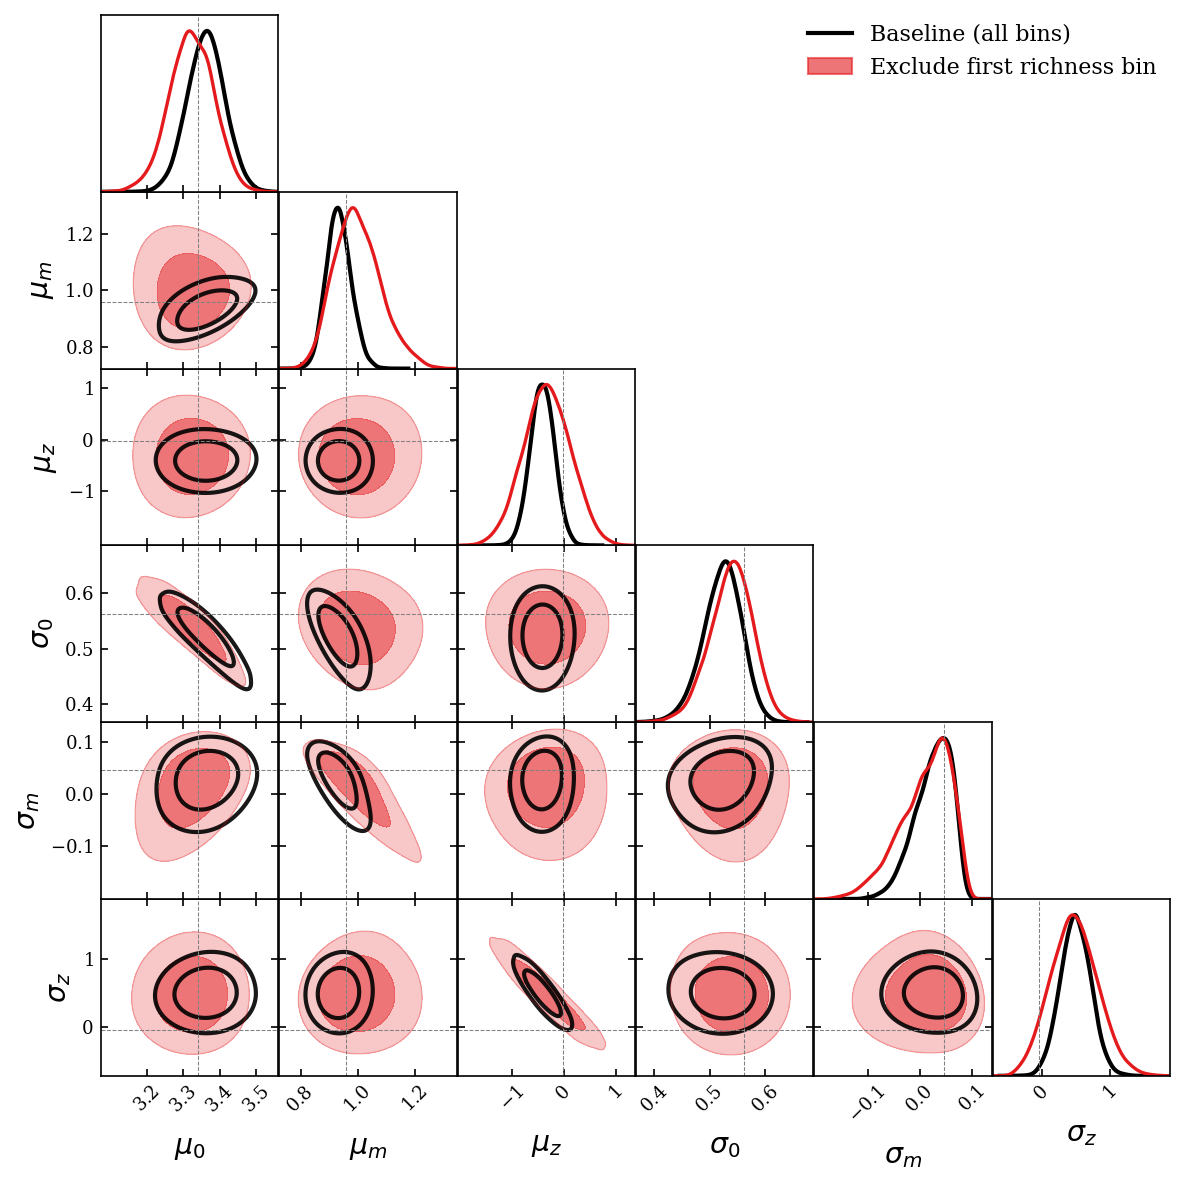


── Baseline (all bins) ──


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

...

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

  Saved 519,400 samples × 8 params → chains/both_exclude_first_richness_bin.fits
  Saved 72,800 samples × 6 params → chains/mor_exclude_first_richness_bin.fits


[PosixPath('chains/mor_exclude_first_richness_bin.fits')]

In [12]:
import sys
sys.path.append("../../")
from clpipeline.utils.cosmosis_mcmc_plots import plot_triangle, ChainStyle, PlotConfig

# ── Paths ─────────────────────────────────────────────────────────────────────

BASELINE = "./baseline/cosmodc2_redmapper_full_analysis/run_in2p3_both/outputs_both/output_rp/number_counts_samples.txt"

EXCLUDE = "./high_completeness_analysis/exclude_first_rich_bin/run_in2p3_both/outputs_both/output_rp/number_counts_samples.txt"


paths = [BASELINE, EXCLUDE]


BASELINE_MOR = "./baseline/cosmodc2_redmapper_full_analysis/run_in2p3_mor/outputs_mor/output_rp/number_counts_samples.txt"

EXCLUDE_MOR = "./high_completeness_analysis/exclude_first_rich_bin/run_in2p3_mor/outputs_both/output_rp/number_counts_samples.txt"   


paths_mor = [BASELINE_MOR,EXCLUDE_MOR]

# ── Parameters (COSMO + MOR) ─────────────────────────────────────────────────
PARAMS_BOTH = [
    (r"\Omega_c", 0.22),
    (r"\sigma_8", 0.80),
    (r"\mu_0",     3.34),
    (r"\mu_m",     0.958236982),
    (r"\mu_z",    -0.0192802),
    (r"\sigma_0",  0.562317194),
    (r"\sigma_m",  0.04552506),
    (r"\sigma_z", -0.0445),
]

# ── Parameters (COSMO + MOR) ─────────────────────────────────────────────────
PARAMS_MOR = [
    (r"\mu_0",     3.34),
    (r"\mu_m",     0.958236982),
    (r"\mu_z",    -0.0192802),
    (r"\sigma_0",  0.562317194),
    (r"\sigma_m",  0.04552506),
    (r"\sigma_z", -0.0445),
]

# ── Styles (3 chains, meaningful comparison) ─────────────────────────────
styles = [
    ChainStyle(
        "Baseline (all bins)",
        filled=False,
        linewidth=2.0,
        color="#000000"
    ),
    ChainStyle(
        "Exclude first richness bin",
        filled=True,
        fill_alpha=0.6,
        linewidth=1.6,
        color="#e41a1c"
    ),
]


# ── Config ───────────────────────────────────────────────────────────────────
cfg = PlotConfig(figsize=8, output_dir="./figures")


# ── Sanity check ─────────────────────────────────────────────────────────────
assert len(paths) == len(styles)


# ── Plot ─────────────────────────────────────────────────────────────────────
samples_both = plot_triangle(
    paths,
    PARAMS_BOTH,
    styles,
    name="selection_exclude_first_bin",
    config=cfg,
    save=False
)

samples_mor = plot_triangle(
    paths_mor,
    PARAMS_MOR,
    styles,
    name="selection_exclude_first_bin",
    config=cfg,
    save=False
)

chains_to_fits(
    samples=[samples_both[1]],
    params=PARAMS_BOTH,
    labels=["both_exclude_first_richness_bin"],
    output_dir="./chains",
)

chains_to_fits(
    samples=[samples_mor[1]],
    params=PARAMS_MOR,
    labels=["mor_exclude_first_richness_bin"],
    output_dir="./chains",
)

LOADING CHAIN FROM FILE:  ./baseline/cosmodc2_redmapper_full_analysis/run_in2p3_both/outputs_both/output_rp/number_counts_samples.txt
Removed no burn in
  Baseline: 1,426,600 samples  (./baseline/cosmodc2_redmapper_full_analysis/run_in2p3_both/outputs_both/output_rp/number_counts_samples.txt)
LOADING CHAIN FROM FILE:  ./hmf_analysis//bocquet16/run_in2p3_both/outputs_both/output_rp/number_counts_samples.txt
Removed no burn in
  Bocquet+16: 957,600 samples  (./hmf_analysis//bocquet16/run_in2p3_both/outputs_both/output_rp/number_counts_samples.txt)
LOADING CHAIN FROM FILE:  ./hmf_analysis//tinker08/run_in2p3_both/outputs_both/output_rp/number_counts_samples.txt
Removed no burn in
  Tinker+08: 718,200 samples  (./hmf_analysis//tinker08/run_in2p3_both/outputs_both/output_rp/number_counts_samples.txt)
LOADING CHAIN FROM FILE:  ./hmf_analysis//tinker10/run_in2p3_both/outputs_both/output_rp/number_counts_samples.txt
Removed no burn in
  Tinker+10: 634,200 samples  (./hmf_analysis//tinker10/run

<IPython.core.display.Math object>

<IPython.core.display.Math object>


── Bocquet+16 ──


<IPython.core.display.Math object>

...

<IPython.core.display.Math object>


── ($\Omega_c{=}0.22,\ \sigma_8{=}0.7$) ──


<IPython.core.display.Math object>

<IPython.core.display.Math object>

deltasigma 0.22/0.7: kept 728511/772800 samples inside the shared box


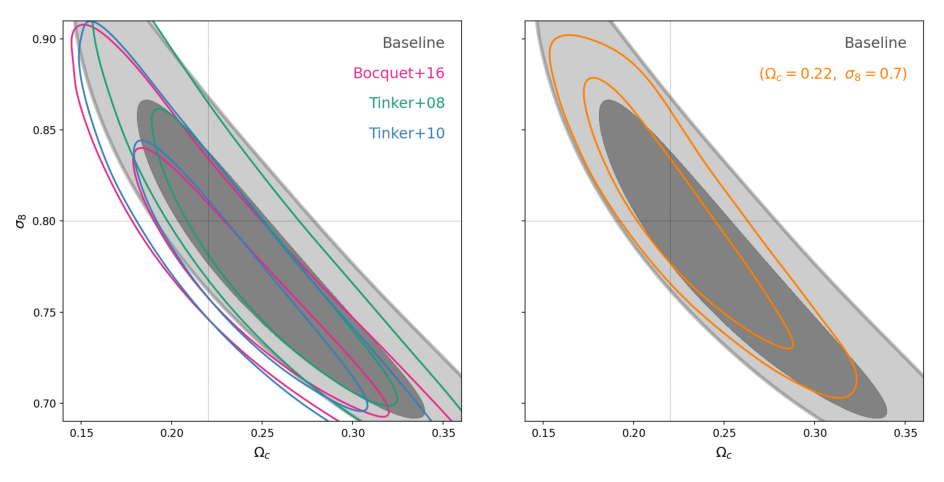

In [13]:
import sys
sys.path.append("../../")
from clpipeline.utils.cosmosis_mcmc_plots import plot_triangle, ChainStyle, PlotConfig
from getdist import plots
import matplotlib.pyplot as plt
from PIL import Image

BASELINE_PATH = "./baseline/cosmodc2_redmapper_full_analysis/run_in2p3_both/outputs_both/output_rp/number_counts_samples.txt"
HMF_DIR      = "./hmf_analysis/"
HMFS_WANTED  = ["bocquet16", "tinker08", "tinker10"]
hmf_paths = [f"{HMF_DIR}/{h}/run_in2p3_both/outputs_both/output_rp/number_counts_samples.txt"
             for h in HMFS_WANTED]
DS_DIR, DS_RUN = "./fiducial_cosmology_analysis", "cosmo_0.22_0.7"
ds_path = f"{DS_DIR}/{DS_RUN}/run_in2p3_both/outputs_both/output_rp/number_counts_samples.txt"

PATHS  = [BASELINE_PATH, *hmf_paths, ds_path]
LABELS = ["Baseline", "Bocquet+16", "Tinker+08", "Tinker+10",
          r"($\Omega_c{=}0.22,\ \sigma_8{=}0.7$)"]
COLORS = ["#4d4d4d", "#e7298a", "#1b9e77", "#377eb8", "#ff7f00"]

LS     = ["-", "-", "-", "-", "-"]
LW     = [2.0, 1.8, 1.8, 1.8, 1.8]
FILLED = [True, False, False, False, False]
FILL_ALPHA = 0.7

PARAMS_COSMO = [(r"\Omega_c", 0.22), (r"\sigma_8", 0.80)]
styles = [ChainStyle(LABELS[0], filled=True, linestyle="-", linewidth=LW[0], fill_alpha=FILL_ALPHA, color=COLORS[0])]
styles += [ChainStyle(l, filled=False, linestyle=ls, linewidth=lw, color=c)
           for l, ls, lw, c in zip(LABELS[1:], LS[1:], LW[1:], COLORS[1:])]
cfg = PlotConfig(figsize=6, output_dir="./figures", burn_fraction=0.3)

_orig_show = plt.show
plt.show = lambda *a, **k: None
try:
    samples = plot_triangle(PATHS, PARAMS_COSMO, styles, name="cosmo_overlay",
                             config=cfg, save=False)
finally:
    plt.show = _orig_show
plt.close('all')

# ── Cut the deltasigma (0.22, 0.7) chain to the shared prior box, in place ───
BOX  = {r"\Omega_c": (0.15, 0.35), r"\sigma_8": (0.70, 0.90)}
s_ds = samples[-1]
ix_oc, ix_s8 = s_ds.index[r"\Omega_c"], s_ds.index[r"\sigma_8"]
mask = ((s_ds.samples[:, ix_oc] >= BOX[r"\Omega_c"][0]) & (s_ds.samples[:, ix_oc] <= BOX[r"\Omega_c"][1]) &
        (s_ds.samples[:, ix_s8] >= BOX[r"\sigma_8"][0]) & (s_ds.samples[:, ix_s8] <= BOX[r"\sigma_8"][1]))
print(f"deltasigma 0.22/0.7: kept {mask.sum()}/{len(mask)} samples inside the shared box")
s_ds.setSamples(s_ds.samples[mask])
samples[-1] = s_ds

# ── apply smoothing config to every chain ─────────────────────────────────────
GETDIST_SETTINGS = {
    "mult_bias_correction_order": 1,
    "boundary_correction_order": 1,
    "smooth_scale_2D": 4,
    "smooth_scale_1D": 3,
}
for s in samples:
    s.updateSettings(GETDIST_SETTINGS)
    s.updateBaseStatistics()

XLIM, YLIM = (0.14, 0.36), (0.69, 0.91)

def make_panel(chain_idxs, title, out_path, show_ylabel=True):
    chains = [samples[i] for i in chain_idxs]
    g = plots.get_subplot_plotter(width_inch=6.5)
    g.settings.num_plot_contours = 2
    g.plot_2d(chains, r"\Omega_c", r"\sigma_8",
              filled=[FILLED[i] for i in chain_idxs],
              colors=[COLORS[i] for i in chain_idxs],
              ls=[LS[i] for i in chain_idxs],
              lws=[LW[i] for i in chain_idxs],
              alphas=[FILL_ALPHA if FILLED[i] else 1.0 for i in chain_idxs])
    ax = g.subplots[0, 0]
    ax.set_xlim(*XLIM); ax.set_ylim(*YLIM)
    ax.axvline(0.22, color='k', ls=':', lw=0.4)
    ax.axhline(0.80, color='k', ls=':', lw=0.4)
    if title:
        ax.set_title(title, fontsize=12)

    if not show_ylabel:
        ax.set_ylabel('')
        ax.tick_params(axis='y', labelleft=False)

    y0, dy = 0.96, 0.075
    for j, i in enumerate(chain_idxs):
        ax.text(0.96, y0 - j * dy, LABELS[i], transform=ax.transAxes,
                 color=COLORS[i], fontsize=15,
                 ha='right', va='top')

    g.fig.subplots_adjust(left=0.18 if show_ylabel else 0.06, right=0.97, bottom=0.13, top=0.90)
    g.fig.savefig(out_path, dpi=150)
    plt.close(g.fig)

make_panel([0, 1, 2, 3], None, "./figures/_panelA.png", show_ylabel=True)
make_panel([0, 4],       None, "./figures/_panelB.png", show_ylabel=False)

# ── stitch the two panels side by side ────────────────────────────────────────
imgA, imgB = Image.open("./figures/_panelA.png"), Image.open("./figures/_panelB.png")
combined = Image.new("RGB", (imgA.width + imgB.width, imgA.height), "white")
combined.paste(imgA, (0, 0))
combined.paste(imgB, (imgA.width, 0))
combined.save("./figures/cosmo_overlay_two_panel.pdf")

plt.figure(figsize=(13, 6))
plt.imshow(combined)
plt.axis('off')
plt.show()

LOADING CHAIN FROM FILE:  ./baseline/cosmodc2_redmapper_full_analysis/run_in2p3_both/outputs_both/output_rp/number_counts_samples.txt
Removed no burn in
  Counts + WL profile: 1,426,600 samples  (./baseline/cosmodc2_redmapper_full_analysis/run_in2p3_both/outputs_both/output_rp/number_counts_samples.txt)

── Counts + WL profile ──


<IPython.core.display.Math object>

<IPython.core.display.Math object>

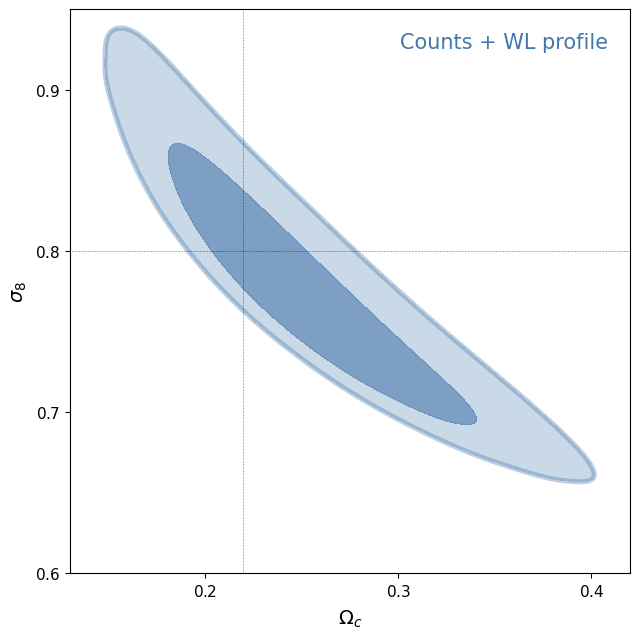

In [14]:
import sys
sys.path.append("../../")
from clpipeline.utils.cosmosis_mcmc_plots import plot_triangle, ChainStyle, PlotConfig
from getdist import plots
import matplotlib.pyplot as plt

BASELINE_PATH = "./baseline/cosmodc2_redmapper_full_analysis/run_in2p3_both/outputs_both/output_rp/number_counts_samples.txt"

PATHS  = [BASELINE_PATH]
LABELS = ["Counts + WL profile"]
COLORS = ["#4477AA"]
LS     = ["-"]
LW     = [2.0]
FILLED = [True]
FILL_ALPHA = 0.7

PARAMS_COSMO = [(r"\Omega_c", 0.22), (r"\sigma_8", 0.80)]

styles = [ChainStyle(LABELS[0], filled=True, linestyle="-", linewidth=LW[0],
                      fill_alpha=FILL_ALPHA, color=COLORS[0])]
cfg = PlotConfig(figsize=6, output_dir="./figures", burn_fraction=0.3)

_orig_show = plt.show
plt.show = lambda *a, **k: None
try:
    samples = plot_triangle(PATHS, PARAMS_COSMO, styles, name="cosmo_baseline",
                             config=cfg, save=False)
finally:
    plt.show = _orig_show
plt.close('all')

GETDIST_SETTINGS = {
    "mult_bias_correction_order": 2,
    "boundary_correction_order": 2,
    "smooth_scale_2D": 4,
    "smooth_scale_1D": 3,
}
for s in samples:
    s.updateSettings(GETDIST_SETTINGS)
    s.updateBaseStatistics()

XLIM, YLIM = (0.13, 0.42), (0.6, 0.95)

g = plots.get_subplot_plotter(width_inch=6.5)
g.settings.num_plot_contours = 2
g.plot_2d(samples, r"\Omega_c", r"\sigma_8",
          filled=FILLED, colors=COLORS, ls=LS, lws=LW,
          alphas=[FILL_ALPHA])

ax = g.subplots[0, 0]
ax.set_xlim(*XLIM); ax.set_ylim(*YLIM)
ax.axvline(0.22, color='k', ls=':', lw=0.4)
ax.axhline(0.80, color='k', ls=':', lw=0.4)

ax.text(0.96, 0.96, LABELS[0], transform=ax.transAxes,
        color=COLORS[0], fontsize=15, ha='right', va='top')

g.fig.subplots_adjust(left=0.18, right=0.97, bottom=0.13, top=0.90)
g.fig.savefig("./figures/cosmo_baseline.pdf", dpi=150)
plt.show()